In [96]:
import sys
from pathlib import Path
import torch

ROOT = Path.cwd().parent  # notebook/ 的 parent
sys.path.insert(0, str(ROOT))

import dlphys.models  # trigger registration
from dlphys.config.base import ExperimentConfig
from dlphys.config.registry import build_model
from dlphys.analysis.jvp import jvp_F
from dlphys.utils.seed import set_seed
from dlphys.analysis.lyapunov_projected import (
    lyapunov_max_benettin_projected_final,
    lyapunov_projected_per_step,
)

set_seed(0, deterministic=True)

L = 20
d_model = 128
d_k = 64
gamma = 0.5

cfg = ExperimentConfig(
    project_name="toy",
    device="cpu",
    seed=10,
    deterministic=True,
    extra={
        "model_name": "toy_attention",
        "model_kwargs": dict(d_model=d_model, d_k=d_k, L=L, num_heads=1, gamma=gamma, phi="identity"),
    }
)
m = build_model(cfg).eval()

B = 1
s = torch.randn(B, L+1, d_model)

# Attention model

In [81]:
project_slot0 = lambda v: v[:, 0, :]  # Pi_x

def F(s_in):
    # IMPORTANT: ensure this returns the next state with the SAME shape [B, L+1, d_model]
    return m(s_in)
s0 = s.clone()
out = lyapunov_projected_per_step(
    F, s0,
    T=2000, burn_in=1800,
    project_fn=project_slot0,
    return_traj=False
)

print("lambda_full_mean:", out["lambda_full_mean"].item())
print("lambda_proj_mean:", out["lambda_proj_mean"].item())

lambda_full_mean: 0.0012490423396229744
lambda_proj_mean: 0.0012340674875304103


In [71]:
from dlphys.analysis.lyapunov import lyapunov_max_benettin

# 用同一个初态（或拷贝一份）
s0 = s.clone()

F = lambda _s: m(_s)

out = lyapunov_max_benettin(
    F, s0,
    T=2000, burn_in=1800,
    return_traj=False
)

print("lambda_hat (per batch):", out["lambda_hat"])
print("lambda_mean:", out["lambda_mean"])


@torch.no_grad()
def sensitivity_profile(m, s, n_trials=5):
    """
    Returns: sens[ L+1 ] where sens[tau] = E || d x_next / d s_tau || (via JVP)
    """
    B, T, d = s.shape
    assert B == 1
    F = lambda _s: m(_s)  # returns full s_next

    sens = torch.zeros(T)
    for tau in range(T):
        vals = []
        for _ in range(n_trials):
            v = torch.zeros_like(s)
            v[:, tau, :] = torch.randn_like(v[:, tau, :])  # perturb only this slot
            jvp = jvp_F(F, s, v)  # shape [1,T,d]
            dxnext = jvp[:, 0, :]  # output token perturbation
            vals.append(dxnext.norm(dim=-1).item())
        sens[tau] = sum(vals) / len(vals)
    return sens

sens = sensitivity_profile(m, s, n_trials=3)
print("sens shape:", sens.shape)
print("sens (first 10):", sens[:10])
print("ratio max/min:", (sens.max()/ (sens.min()+1e-12)).item())

p = sens / (sens.sum() + 1e-12)
entropy = (-(p * (p + 1e-12).log()).sum()).item()
entropy_uniform = torch.log(torch.tensor(float(L+1))).item()
print("entropy proxy:", entropy, "uniform entropy:", entropy_uniform)

lambda_hat (per batch): tensor([0.0051])
lambda_mean: tensor(0.0051)
sens shape: torch.Size([21])
sens (first 10): tensor([2.3167, 0.7843, 0.5551, 0.1384, 0.1295, 0.9394, 0.5145, 0.4241, 0.1169,
        0.4636])
ratio max/min: 25.9398250579834
entropy proxy: 2.720716953277588 uniform entropy: 3.044522523880005


# Lyapunov index vs dk

gamma=0.3 d_model= 256  lambda_full=+0.001020  lambda_proj=+0.001008
gamma=0.3 d_model= 512  lambda_full=-0.000597  lambda_proj=-0.000601
gamma=0.3 d_model=1024  lambda_full=-0.000101  lambda_proj=-0.000098
gamma=0.3 d_model=2028  lambda_full=-0.000080  lambda_proj=-0.000084
gamma=0.5 d_model= 256  lambda_full=+0.001138  lambda_proj=+0.001137
gamma=0.5 d_model= 512  lambda_full=-0.000499  lambda_proj=-0.000500
gamma=0.5 d_model=1024  lambda_full=-0.000154  lambda_proj=-0.000150
gamma=0.5 d_model=2028  lambda_full=-0.000022  lambda_proj=-0.000031
gamma=0.7 d_model= 256  lambda_full=+0.001141  lambda_proj=+0.001147
gamma=0.7 d_model= 512  lambda_full=-0.000485  lambda_proj=-0.000485
gamma=0.7 d_model=1024  lambda_full=-0.000121  lambda_proj=-0.000116
gamma=0.7 d_model=2028  lambda_full=-0.000026  lambda_proj=-0.000034
gamma=0.9 d_model= 256  lambda_full=+0.001137  lambda_proj=+0.001145
gamma=0.9 d_model= 512  lambda_full=-0.000481  lambda_proj=-0.000481
gamma=0.9 d_model=1024  lambda_ful

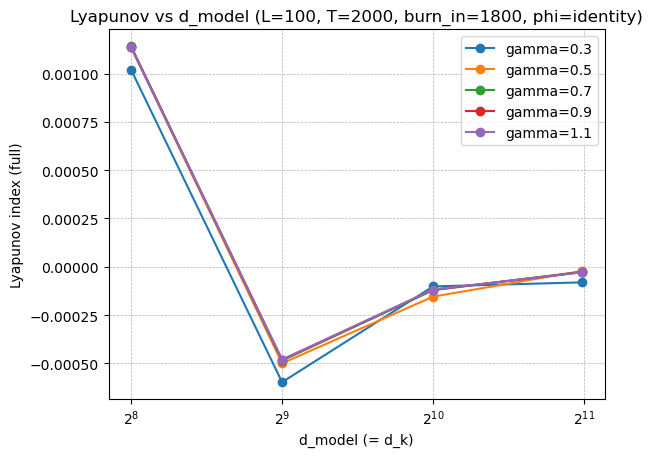

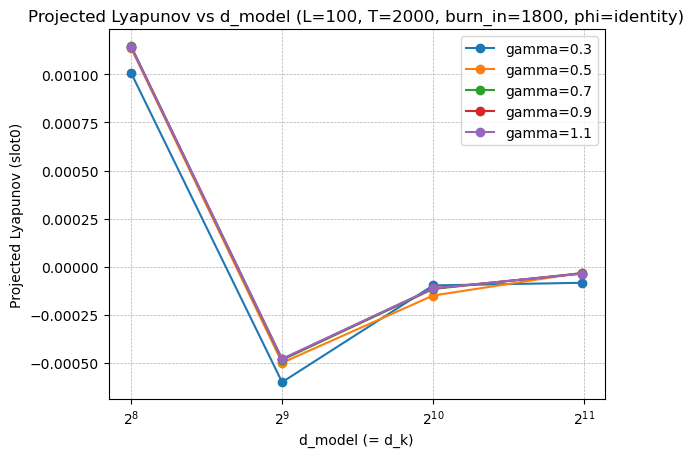

In [92]:
import sys
from pathlib import Path
import math
import torch
import matplotlib.pyplot as plt

# --- Path / imports (same style as yours) ---
ROOT = Path.cwd().parent  # notebook/ 的 parent
sys.path.insert(0, str(ROOT))

import dlphys.models  # trigger registration
from dlphys.config.base import ExperimentConfig
from dlphys.config.registry import build_model
from dlphys.utils.seed import set_seed

# If you put the projected code in dlphys/analysis/lyapunov_projected.py
from dlphys.analysis.lyapunov_projected import lyapunov_projected_per_step


# -----------------------
# Experiment configuration
# -----------------------
device = "cpu"
set_seed(0, deterministic=True)

gammas = [0.3, 0.5, 0.7, 0.9, 1.1]
# Choose a sweep for d_model (and d_k = d_model)
d_models = [256, 512, 1024, 2028]  # edit if you want

L = 100
num_heads = 1
phi = "identity"

# Lyapunov settings
B = 1
T = 2000
burn_in = 1800

# Projection Pi_x: slot0
project_slot0 = lambda v: v[:, 0, :]

def build_toy_attention(d_model: int, gamma: float):
    cfg = ExperimentConfig(
        project_name="toy",
        device=device,
        seed=10,
        deterministic=True,
        extra={
            "model_name": "toy_attention",
            "model_kwargs": dict(
                d_model=d_model,
                d_k=d_model,       # enforce d_k = d_model
                L=L,
                num_heads=num_heads,
                gamma=gamma,
                phi=phi,
            ),
        }
    )
    m = build_model(cfg).eval()
    return m

def F_factory(m):
    def F(s_in):
        return m(s_in)
    return F


# -----------------------
# Run sweep
# -----------------------
results = {}  # gamma -> list of (d_model, lambda_full_mean, lambda_proj_mean)
for gamma in gammas:
    triples = []
    for d_model in d_models:
        set_seed(0, deterministic=True)  # keep comparability across runs

        m = build_toy_attention(d_model=d_model, gamma=gamma)
        F = F_factory(m)

        # fresh random initial state each run (same seed resets, so comparable)
        s0 = torch.randn(B, L + 1, d_model, device=device)

        out = lyapunov_projected_per_step(
            F, s0,
            T=T,
            burn_in=burn_in,
            project_fn=project_slot0,
            return_traj=False
        )

        lam_full = float(out["lambda_full_mean"])
        lam_proj = float(out["lambda_proj_mean"])
        triples.append((d_model, lam_full, lam_proj))

        print(f"gamma={gamma:.1f} d_model={d_model:4d}  lambda_full={lam_full:+.6f}  lambda_proj={lam_proj:+.6f}")

    results[gamma] = triples


# -----------------------
# Plot: Lyapunov vs d_model, one line per gamma
# -----------------------
plt.figure()
for gamma in gammas:
    triples = results[gamma]
    xs = [t[0] for t in triples]
    ys = [t[1] for t in triples]  # <-- full Lyapunov
    plt.plot(xs, ys, marker="o", label=f"gamma={gamma}")

plt.xscale("log", base=2)  # optional; comment out if you prefer linear x
plt.xlabel("d_model (= d_k)")
plt.ylabel("Lyapunov index (full)")
plt.title(f"Lyapunov vs d_model (L={L}, T={T}, burn_in={burn_in}, phi={phi})")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


# -----------------------
# Optional second plot: projected (slot0) Lyapunov vs d_model
# -----------------------
plt.figure()
for gamma in gammas:
    triples = results[gamma]
    xs = [t[0] for t in triples]
    ys = [t[2] for t in triples]  # <-- projected Lyapunov (slot0)
    plt.plot(xs, ys, marker="o", label=f"gamma={gamma}")

plt.xscale("log", base=2)  # optional
plt.xlabel("d_model (= d_k)")
plt.ylabel("Projected Lyapunov (slot0)")
plt.title(f"Projected Lyapunov vs d_model (L={L}, T={T}, burn_in={burn_in}, phi={phi})")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

gamma=0.3  entropy_proxy=1.704829  uniform=4.615120  (H/uniform)=0.3694
gamma=0.5  entropy_proxy=4.119802  uniform=4.615120  (H/uniform)=0.8927
gamma=0.7  entropy_proxy=4.583857  uniform=4.615120  (H/uniform)=0.9932
gamma=0.9  entropy_proxy=4.613938  uniform=4.615120  (H/uniform)=0.9997
gamma=1.1  entropy_proxy=4.614980  uniform=4.615120  (H/uniform)=1.0000


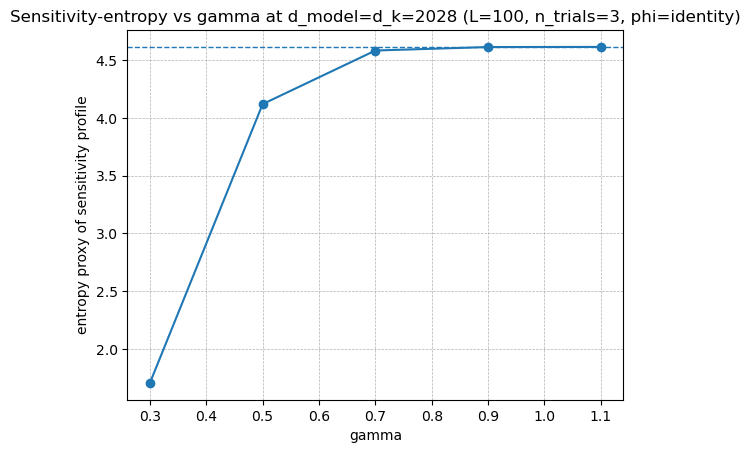

In [94]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import dlphys.models
from dlphys.config.base import ExperimentConfig
from dlphys.config.registry import build_model
from dlphys.analysis.jvp import jvp_F
from dlphys.utils.seed import set_seed


@torch.no_grad()
def sensitivity_profile(m, s, n_trials=5):
    """
    Returns: sens[Tmem] where sens[tau] = E || d x_next / d s_tau || (via JVP)
    s shape: [1, Tmem, d_model], with Tmem = L+1
    """
    B, Tmem, d = s.shape
    assert B == 1

    F = lambda _s: m(_s)  # returns full s_next

    sens = torch.zeros(Tmem, device=s.device, dtype=s.dtype)
    for tau in range(Tmem):
        vals = []
        for _ in range(n_trials):
            v = torch.zeros_like(s)
            v[:, tau, :] = torch.randn_like(v[:, tau, :])  # perturb only this slot
            jvp = jvp_F(F, s, v)          # shape [1, Tmem, d]
            dxnext = jvp[:, 0, :]         # perturbation of output token x_{t+1}
            vals.append(dxnext.norm(dim=-1).item())
        sens[tau] = sum(vals) / len(vals)
    return sens.cpu()


def entropy_from_sens(sens, eps=1e-12):
    p = sens / (sens.sum() + eps)
    H = (-(p * (p + eps).log()).sum()).item()
    return H


# -----------------------
# Sweep settings
# -----------------------
device = "cpu"
set_seed(0, deterministic=True)

L = 100
d_model = 2028
d_k = 2028
num_heads = 1
phi = "identity"

gamma_list = [0.3, 0.5, 0.7, 0.9, 1.1]

# Sensitivity settings
n_trials = 3   # increase to 10 if you want smoother entropy
B = 1

# Fix ONE state s for fair comparison across gammas
s = torch.randn(B, L + 1, d_model, device=device)


def build_toy_attention(gamma):
    cfg = ExperimentConfig(
        project_name="toy",
        device=device,
        seed=0,
        deterministic=True,
        extra={
            "model_name": "toy_attention",
            "model_kwargs": dict(
                d_model=d_model,
                d_k=d_k,
                L=L,
                num_heads=num_heads,
                gamma=gamma,
                phi=phi,
            ),
        }
    )
    return build_model(cfg).eval()


# -----------------------
# Run sweep
# -----------------------
entropy_vals = []
entropy_uniform = torch.log(torch.tensor(float(L + 1))).item()

for gamma in gamma_list:
    # rebuild model for each gamma
    m = build_toy_attention(gamma)

    sens = sensitivity_profile(m, s, n_trials=n_trials)
    H = entropy_from_sens(sens)

    entropy_vals.append(H)

    print(f"gamma={gamma:>3}  entropy_proxy={H:.6f}  uniform={entropy_uniform:.6f}  (H/uniform)={H/entropy_uniform:.4f}")

# -----------------------
# Plot
# -----------------------
plt.figure()
plt.plot(gamma_list, entropy_vals, marker="o")
plt.axhline(entropy_uniform, linestyle="--", linewidth=1.0)
plt.xlabel("gamma")
plt.ylabel("entropy proxy of sensitivity profile")
plt.title(f"Sensitivity-entropy vs gamma at d_model=d_k={d_model} (L={L}, n_trials={n_trials}, phi={phi})")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()